# Notebook 02: Feature Engineering

**Project:** MAP Dryer AI  
**Purpose:** transform the canonical dryer prototype source into a consistent, model-ready feature table.

The notebook standardises data types, builds a timestamp, prepares a complete-case table, explores baseline relationships, and derives process-informed features.

## Inputs and outputs

- **Input:** `data/processed/MAP_Dryer_Canonical_5s.csv` (audited in Notebook 01)
- **Output:** `data/processed/MAP_Dryer_Lab_Aligned_16.csv` and `artifacts/notebook02_feature_handoff.json`
- **Figure outputs:** `figures/02_Feature_Engineering/`
- **Prototype feature dictionary:** `config/data_dictionary.yaml`

## Reading guide

All transformations are applied in sequence. The final export is the hand-off artifact for Notebooks 03 and 04.


## 1. Import analysis libraries

Load the libraries needed for data handling, visualisation, statistics, and the downstream modelling workflow.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.feature_catalog import (
    feature_axis_label,
    load_feature_catalog,
    select_feature_catalog,
)
from data.project_paths import find_project_root
from features.engineering import recompute_engineered_features
from features.engineering import ENGINEERED_FEATURES

PROJECT_ROOT = find_project_root()
FIGURE_OUTPUT_DIR = PROJECT_ROOT / "figures" / "02_Feature_Engineering"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DICTIONARY_PATH = PROJECT_ROOT / "config" / "data_dictionary.yaml"
feature_catalog = load_feature_catalog(DATA_DICTIONARY_PATH)

sns.set_theme(style="whitegrid")
# Arial has no U+2082 SUBSCRIPT TWO; passing the stack through
# font.family enables matplotlib per-glyph fallback so "H₂O" renders.
plt.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
pd.set_option("display.max_columns", None)


## Prototype feature dictionary


In [2]:
FEATURE_ENGINEERING_FIELDS = [
    "date", "time", "timestamp", "dryer_air_temperature",
    "cooler_air_temperature", "air_flow_rate", "wet_product_feed_rate",
    "product_inlet_temperature", "residence_time", "vacuum",
    "steam_pressure", "fan_speed", "product_density",
    "final_product_temp", "final_moisture_h₂o", "temperature_drop",
    "air_product_delta", "air_per_feed", "steam_temp_interaction",
    "heating_index",
]
display(select_feature_catalog(feature_catalog, FEATURE_ENGINEERING_FIELDS))
print("Data dictionary version:", feature_catalog.attrs["version"])


,display_name,unit,unit_status,role,interpretation
feature,,,,,
date,Date,calendar date,defined,identifier,Calendar component of the observation timestamp.
time,Time,clock time,defined,identifier,Clock component of the observation timestamp.
timestamp,Timestamp,datetime,defined,identifier,Date and time combined for chronological order...
dryer_air_temperature,Dryer air temperature,°C,prototype_unit,process_input,Dryer inlet-air temperature.
cooler_air_temperature,Cooler air temperature,°C,prototype_unit,process_input,Cooling-air temperature.
air_flow_rate,Air flow rate,m³/h,defined,process_input,Volumetric airflow rate in cubic metres per hour.
wet_product_feed_rate,Wet product feed rate,m³/h,defined,process_input,Volumetric wet-product feed rate in cubic metr...
product_inlet_temperature,Product inlet temperature,°C,prototype_unit,process_input,Product temperature at dryer entry.
residence_time,Residence time,min,prototype_unit,process_input,Time spent in the drying process.


Data dictionary version: map_dryer_data_dictionary_v1.2


### Interpretation guardrails

- The complete-case table contains only rows with every required modelling value present; the number removed is printed explicitly.
- Pearson correlation describes linear association, not causation.
- `air_per_feed`, `steam_temp_interaction`, and `heating_index` are calculated model features; their formulas and prototype units are shown above.


## 2. Load the canonical Notebook 01 handoff

Build the residence-aware laboratory handoff directly from the canonical CSV.
The 16 modelling inputs retain the original Notebook 02 feature names: direct
process values, prior density/temperature results, and the five engineered
features. No mean/std feature replacement is used.


In [3]:
from canonical_pipeline import ALIGNED_PATH, build_feature_handoff

aligned_features, handoff = build_feature_handoff()
OUTPUT_PATH = ALIGNED_PATH

dryerMAP = pd.DataFrame({
    "timestamp": pd.to_datetime(aligned_features.index),
    "dryer_air_temperature": aligned_features["dryer_air_temperature"],
    "cooler_air_temperature": aligned_features["cooler_air_temperature"],
    "air_flow_rate": aligned_features["air_flow_rate"],
    "wet_product_feed_rate": aligned_features["wet_product_feed_rate"],
    "product_inlet_temperature": aligned_features["product_inlet_temperature"],
    "residence_time": aligned_features["residence_time"],
    "vacuum": aligned_features["vacuum"],
    "steam_pressure": aligned_features["steam_pressure"],
    "fan_speed": aligned_features["fan_speed"],
    "product_density": aligned_features["product_density"],
    "final_product_temp": aligned_features["final_product_temp"],
    "final_moisture_h₂o": aligned_features["Final Moisture (%H2O)"],
})
dryerMAP.insert(0, "time", dryerMAP["timestamp"].dt.time)
dryerMAP.insert(0, "date", dryerMAP["timestamp"].dt.normalize())

print(f"Canonical supervised rows: {handoff['supervised_rows']:,}")
print(f"Governed feature count: {handoff['feature_count']}")
print(f"Governed output: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
dryerMAP.info()


Canonical supervised rows: 1,103
Governed feature count: 16
Governed output: data\processed\MAP_Dryer_Lab_Aligned_16.csv
<class 'pandas.DataFrame'>
DatetimeIndex: 1103 entries, 2026-04-16 02:00:00 to 2026-07-16 22:00:00
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1103 non-null   datetime64[us]
 1   time                       1103 non-null   object        
 2   timestamp                  1103 non-null   datetime64[us]
 3   dryer_air_temperature      1103 non-null   float64       
 4   cooler_air_temperature     1103 non-null   float64       
 5   air_flow_rate              1103 non-null   float64       
 6   wet_product_feed_rate      1103 non-null   float64       
 7   product_inlet_temperature  1103 non-null   float64       
 8   residence_time             1103 non-null   float64       
 9   vacuum                     1103 non-null   float6

## 3. Standardise data types and create a timestamp

Convert the date, time, target, and selected process variables to suitable numeric or temporal types. Combining the date and time fields creates a single chronological `timestamp` for later time-aware analysis.


In [4]:
dryerMAP["date"] = pd.to_datetime(
    dryerMAP["date"],
    dayfirst=True
)


In [5]:
dryerMAP["time"] = pd.to_datetime(
    dryerMAP["time"],
    format="%H:%M:%S"
).dt.time


In [6]:
dryerMAP["timestamp"] = pd.to_datetime(
    dryerMAP["date"].dt.strftime("%Y-%m-%d") + " " + dryerMAP["time"].astype(str)
)


In [7]:
dryerMAP["product_density"] = pd.to_numeric(
    dryerMAP["product_density"],
    errors="coerce"
)


In [8]:
dryerMAP["final_moisture_h₂o"] = pd.to_numeric(
    dryerMAP["final_moisture_h₂o"],
    errors="coerce"
)


In [9]:
cols = [
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed"
]

dryerMAP[cols] = dryerMAP[cols].astype(float)


## 4. Verify the transformed dataset

Review the resulting column types and non-null counts after standardisation. This confirms that the fields used in the next steps have the expected representation.


In [10]:
dryerMAP.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 1103 entries, 2026-04-16 02:00:00 to 2026-07-16 22:00:00
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1103 non-null   datetime64[us]
 1   time                       1103 non-null   object        
 2   timestamp                  1103 non-null   datetime64[us]
 3   dryer_air_temperature      1103 non-null   float64       
 4   cooler_air_temperature     1103 non-null   float64       
 5   air_flow_rate              1103 non-null   float64       
 6   wet_product_feed_rate      1103 non-null   float64       
 7   product_inlet_temperature  1103 non-null   float64       
 8   residence_time             1103 non-null   float64       
 9   vacuum                     1103 non-null   float64       
 10  steam_pressure             1103 non-null   float64       
 11  fan_speed                  1103 non-null   f

## 5. Confirm the aligned modelling table

Notebook 02 rejects the single initial timestamp that lacks sufficient causal
process history. Density and product temperature are the most recent strictly
previous laboratory results; the moisture target is never forward-filled.


In [11]:
print(f"Aligned laboratory rows: {len(dryerMAP):,}")
dryerMAP_model = dryerMAP.dropna().copy()
print(f"Complete aligned rows: {len(dryerMAP_model):,}")
print(f"Rows removed here: {len(dryerMAP) - len(dryerMAP_model):,}")


Aligned laboratory rows: 1,103
Complete aligned rows: 1,103
Rows removed here: 0


## 6. Inspect distributions before modelling

A boxplot gives a quick visual check of scale, spread, and potential outliers across the available numerical variables.


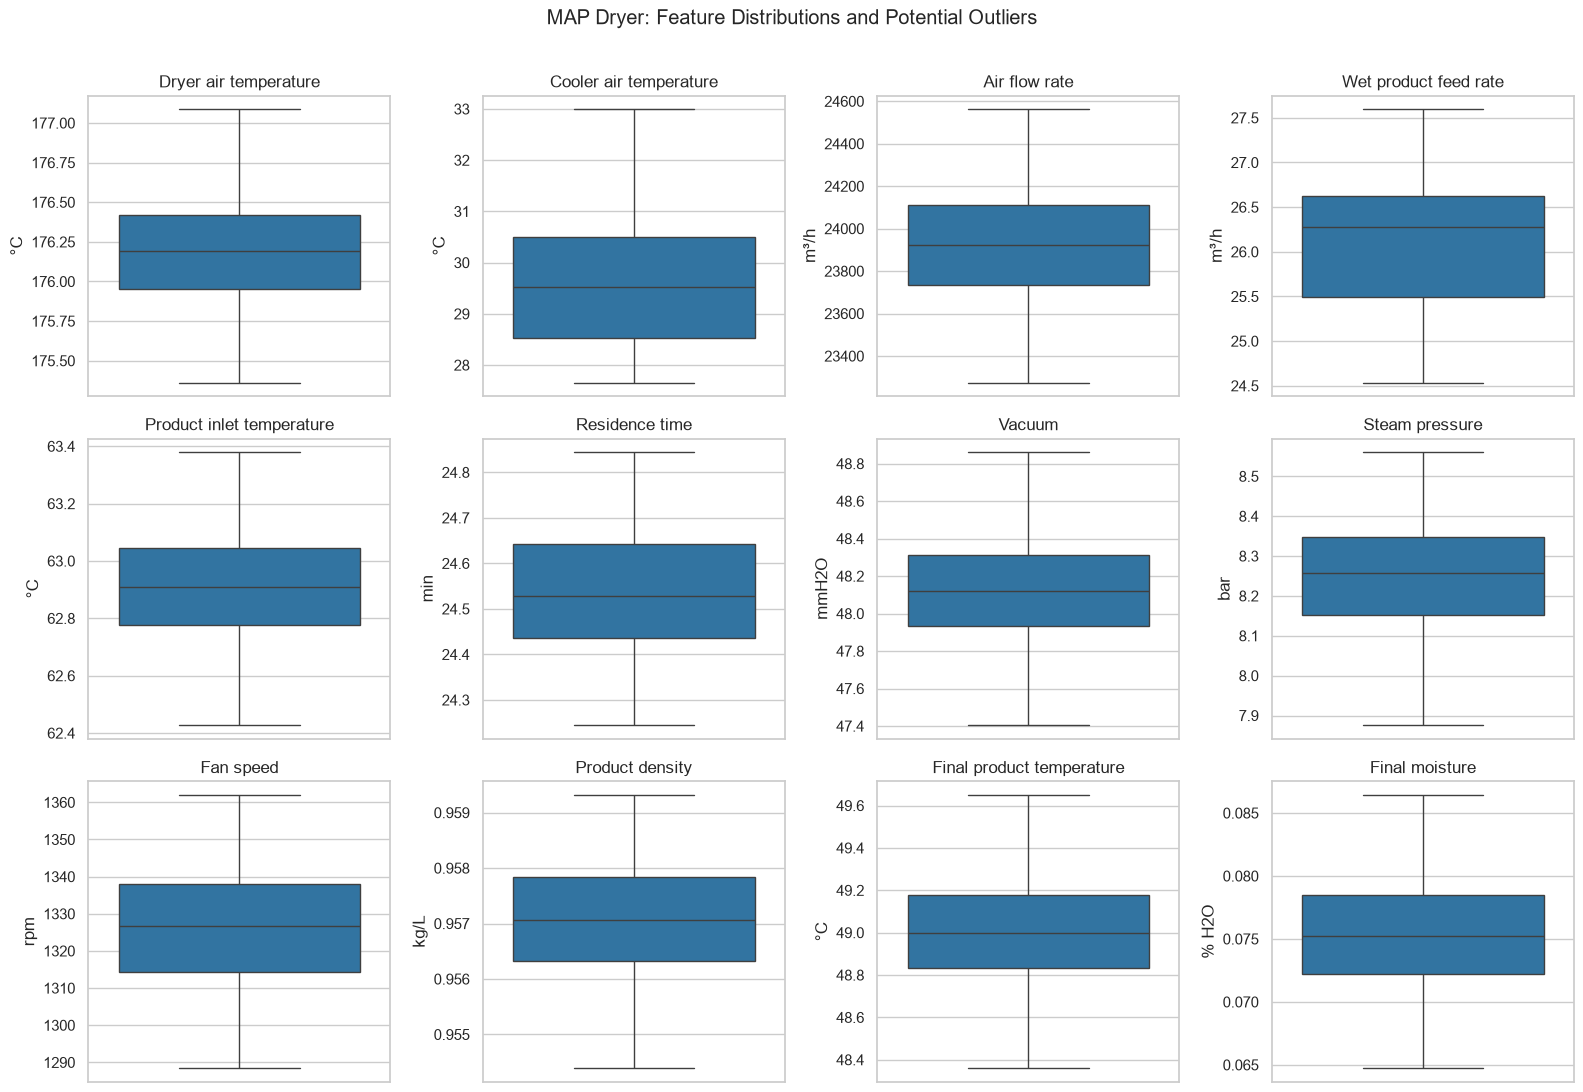

In [12]:
numeric_features = [
    feature
    for feature in dryerMAP_model.select_dtypes(include="number").columns
    if feature in feature_catalog.index
]
n_columns = 4
n_rows = int(np.ceil(len(numeric_features) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 3.6 * n_rows))
axes = np.asarray(axes).reshape(-1)

for axis, feature in zip(axes, numeric_features):
    sns.boxplot(y=dryerMAP_model[feature], color="tab:blue", ax=axis)
    axis.set_title(feature_catalog.loc[feature, "display_name"])
    axis.set_ylabel(feature_catalog.loc[feature, "unit"])
    axis.set_xlabel("")
for axis in axes[len(numeric_features):]:
    axis.set_visible(False)

fig.suptitle("MAP Dryer: Feature Distributions and Potential Outliers", y=1.01)
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_feature_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 7. Establish baseline correlations

Calculate and visualise Pearson correlations among numeric variables. This is exploratory evidence, not a claim of causation, and helps identify relationships worth examining during modelling.


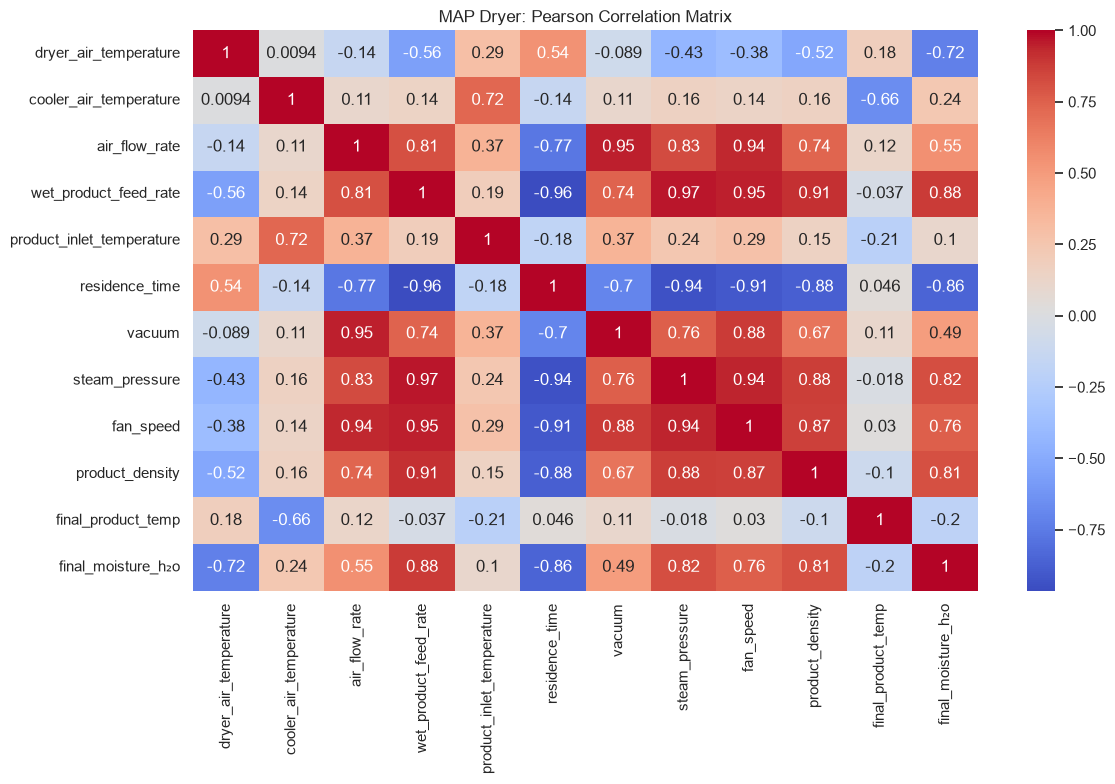

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    dryerMAP_model.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("MAP Dryer: Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "02_pearson_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 8. Examine relationships with the quality target

Convert the final-moisture target to numeric form and rank its linear correlations with the available numeric variables. This provides a baseline before engineered features are added.


In [14]:
target = next(c for c in dryerMAP.columns if "final_moisture" in c)

dryerMAP[target] = pd.to_numeric(
    dryerMAP[target].astype(str).str.replace("%", "", regex=False),
    errors="coerce",
)
corr_with_target = (
    dryerMAP.corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

print(corr_with_target)


final_moisture_h₂o           1.000000
wet_product_feed_rate        0.879606
steam_pressure               0.821037
product_density              0.810913
fan_speed                    0.761867
air_flow_rate                0.554963
vacuum                       0.490921
cooler_air_temperature       0.236410
product_inlet_temperature    0.103780
final_product_temp          -0.196330
dryer_air_temperature       -0.719006
residence_time              -0.855779
Name: final_moisture_h₂o, dtype: float64


## 9. Create process-informed features

The following derived variables express useful process relationships:

- `temperature_drop`: dryer-air temperature minus final-product temperature
- `air_product_delta`: dryer-air temperature minus product-inlet temperature
- `air_per_feed`: air-flow rate per wet-product feed rate
- `steam_temp_interaction`: steam pressure multiplied by dryer-air temperature
- `heating_index`: residence time multiplied by dryer-air temperature

The shared `features.engineering` transformation creates all five columns in one reproducible step.


In [15]:
dryerMAP_model = recompute_engineered_features(dryerMAP_model)
display(dryerMAP_model[list(ENGINEERED_FEATURES)].head())


,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
Sample Timestamp,,,,,
2026-04-16 02:00:00,127.567592,113.480610,904.767880,1472.587488,4310.601796
2026-04-16 04:00:00,127.141793,113.233845,903.452058,1477.012286,4301.957989
2026-04-16 06:00:00,127.016968,113.125553,905.669049,1479.536275,4296.795195
2026-04-16 08:00:00,127.564114,113.108517,904.965252,1469.897746,4301.383849
2026-04-16 10:00:00,127.516507,113.144593,902.339660,1480.708348,4300.288596


## 10. Inspect the engineered feature table

List the final columns and preview the first records to confirm that the derived variables were added as intended.


In [16]:
dryerMAP_model.columns.tolist()


['date',
 'time',
 'timestamp',
 'dryer_air_temperature',
 'cooler_air_temperature',
 'air_flow_rate',
 'wet_product_feed_rate',
 'product_inlet_temperature',
 'residence_time',
 'vacuum',
 'steam_pressure',
 'fan_speed',
 'product_density',
 'final_product_temp',
 'final_moisture_h₂o',
 'temperature_drop',
 'air_product_delta',
 'air_per_feed',
 'steam_temp_interaction',
 'heating_index']

In [17]:
dryerMAP_model.head()


,date,time,timestamp,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
Sample Timestamp,,,,,,,,,,,,,,,,,,,,
2026-04-16 02:00:00,2026-04-16,02:00:00,2026-04-16 02:00:00,176.386871,28.788322,24080.343750,26.614941,62.906261,24.438337,48.143120,8.348623,1333.375977,0.957827,48.819279,0.078586,127.567592,113.480610,904.767880,1472.587488,4310.601796
2026-04-16 04:00:00,2026-04-16,04:00:00,2026-04-16 04:00:00,176.325211,29.371353,24131.474609,26.710299,63.091366,24.397861,48.377773,8.376637,1339.708374,0.957757,49.183418,0.077713,127.141793,113.233845,903.452058,1477.012286,4301.957989
2026-04-16 06:00:00,2026-04-16,06:00:00,2026-04-16 06:00:00,176.298935,30.183477,24223.722656,26.746771,63.173382,24.372213,48.470203,8.392202,1340.537598,0.957155,49.281967,0.077810,127.016968,113.125553,905.669049,1479.536275,4296.795195
2026-04-16 08:00:00,2026-04-16,08:00:00,2026-04-16 08:00:00,176.333313,30.894432,24237.878906,26.783215,63.224796,24.393484,48.433044,8.335905,1342.057739,0.957491,48.769199,0.075195,127.564114,113.108517,904.965252,1469.897746,4301.383849
2026-04-16 10:00:00,2026-04-16,10:00:00,2026-04-16 10:00:00,176.263535,31.169731,24271.029297,26.897886,63.118942,24.396927,48.482235,8.400537,1346.523071,0.958166,48.747028,0.079999,127.516507,113.144593,902.339660,1480.708348,4300.288596


## 11. Visualise and rank engineered features

Plot each engineered feature against final moisture, then rank all numeric features by the absolute size of their Pearson correlation with the target. These views help prioritise candidates for the soft-sensor models.


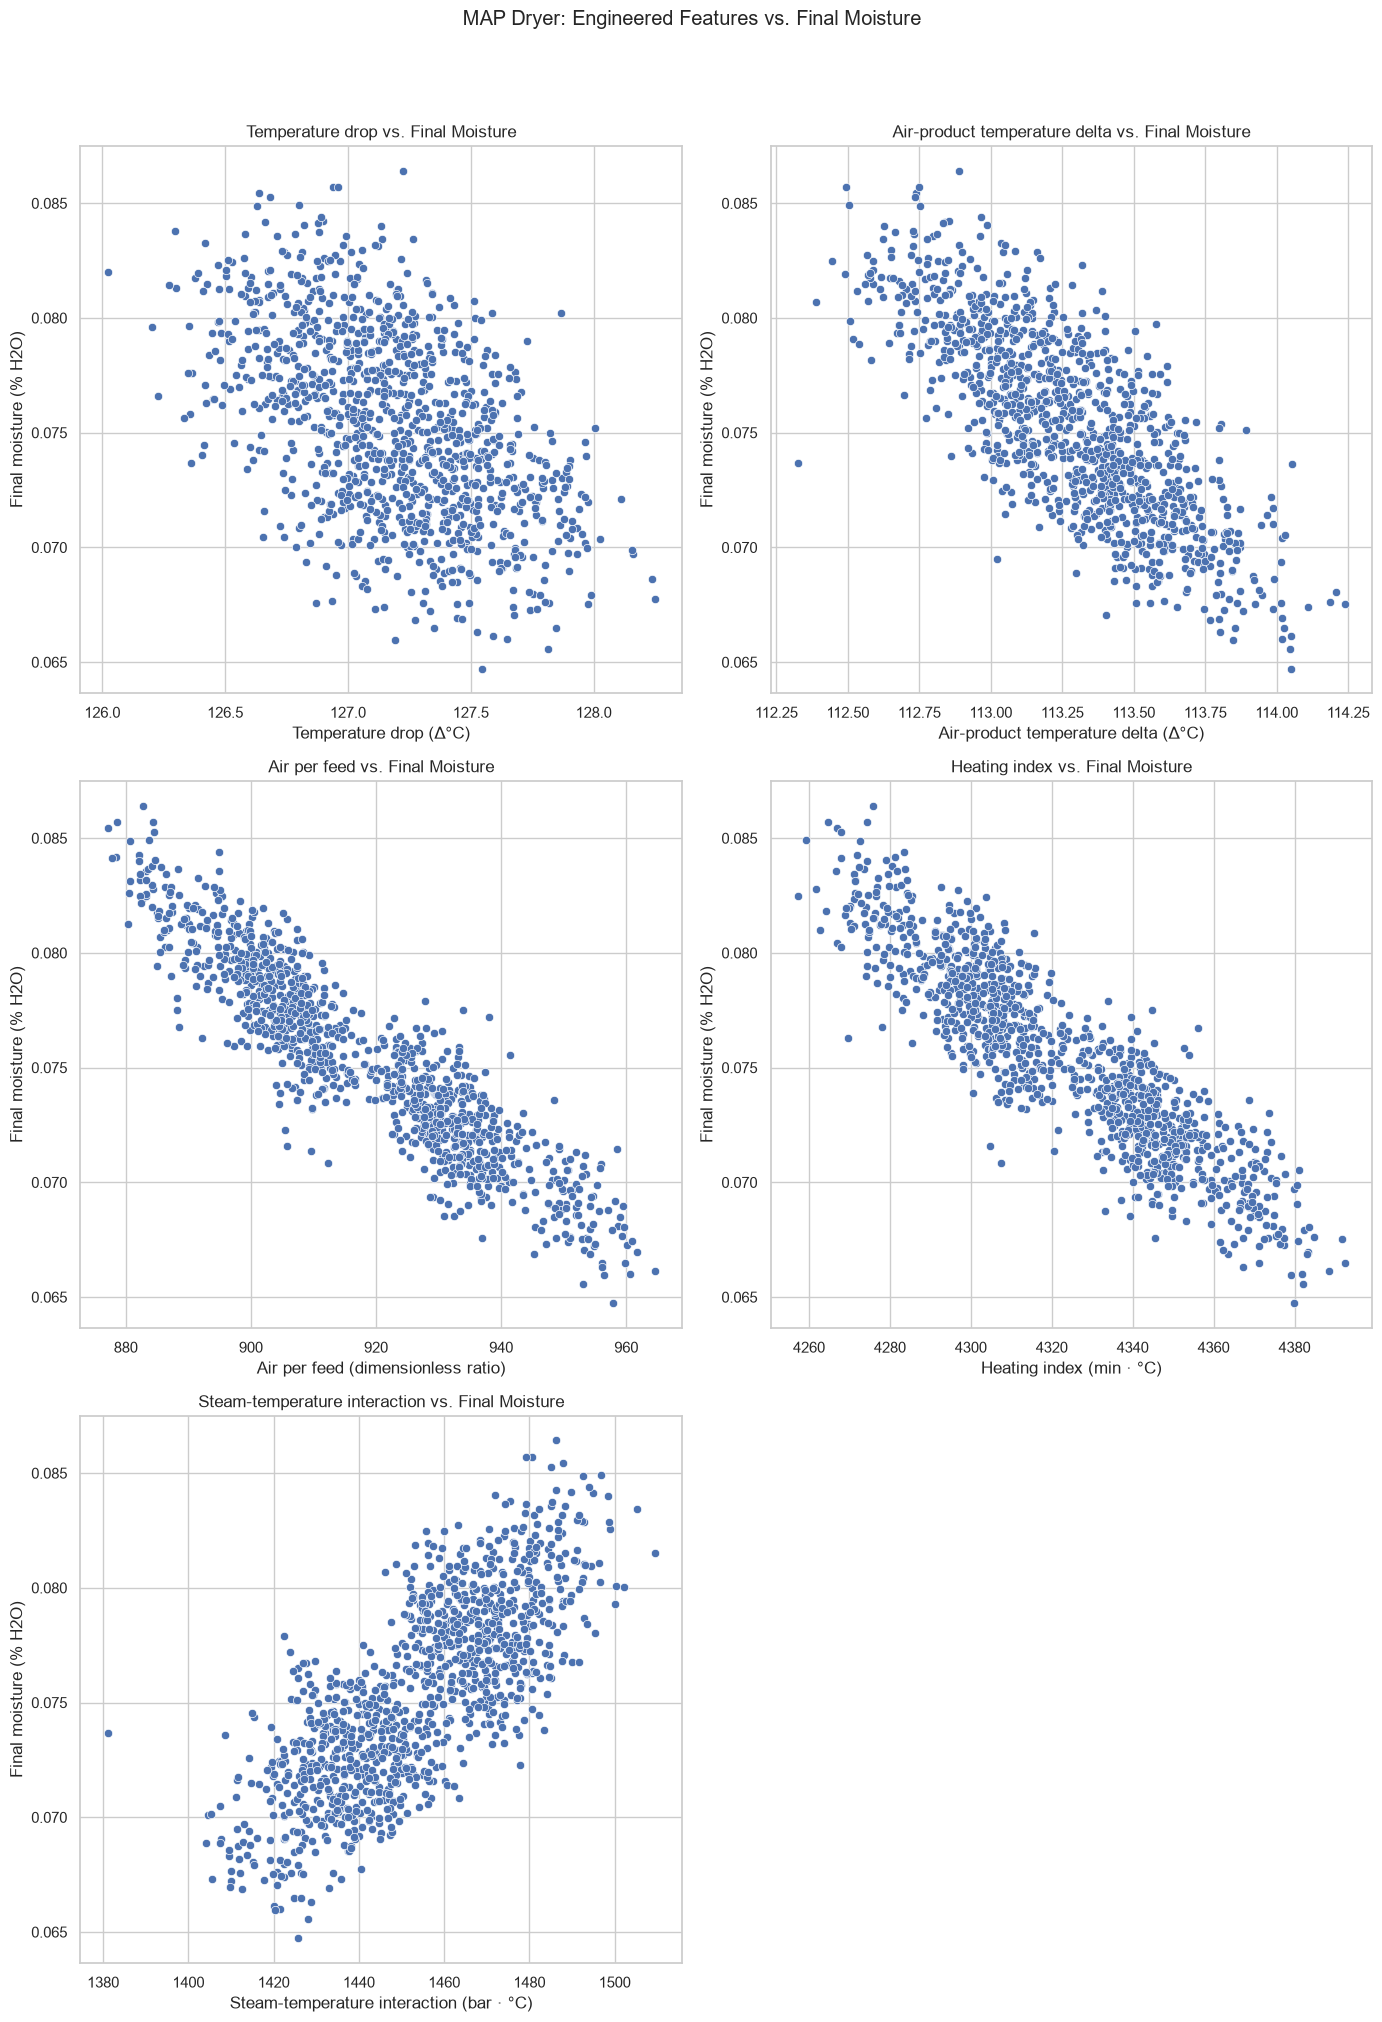

In [18]:
engineered_features = [
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "heating_index",
    "steam_temp_interaction"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 20))
fig.suptitle("MAP Dryer: Engineered Features vs. Final Moisture", y=1.01)
axes = axes.flatten()

for ax, feature in zip(axes, engineered_features):
    sns.scatterplot(
        data=dryerMAP_model,
        x=feature,
        y="final_moisture_h₂o",
        ax=ax
    )
    display_name = feature_catalog.loc[feature, "display_name"]
    ax.set_title(f"{display_name} vs. Final Moisture")
    ax.set_xlabel(feature_axis_label(feature_catalog, feature))
    ax.set_ylabel(feature_axis_label(feature_catalog, "final_moisture_h₂o"))

for ax in axes[len(engineered_features):]:
    ax.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(
    FIGURE_OUTPUT_DIR / "03_engineered_features_vs_final_moisture.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [19]:
corr = dryerMAP_model.corr(numeric_only=True)["final_moisture_h₂o"]

corr_df = (
    corr.drop("final_moisture_h₂o")
        .to_frame(name="Correlation")
)

corr_df["Absolute Correlation"] = corr_df["Correlation"].abs()

corr_df = corr_df.sort_values(
    by="Absolute Correlation",
    ascending=False
)

display(corr_df)


,Correlation,Absolute Correlation
air_per_feed,-0.919561,0.919561
heating_index,-0.902920,0.902920
wet_product_feed_rate,0.879606,0.879606
residence_time,-0.855779,0.855779
steam_pressure,0.821037,0.821037
product_density,0.810913,0.810913
air_product_delta,-0.783319,0.783319
steam_temp_interaction,0.768085,0.768085
fan_speed,0.761867,0.761867
dryer_air_temperature,-0.719006,0.719006


## 12. Verify the governed model-ready export

The canonical builder has already written the exact 16-feature handoff. This
cell verifies its location and schema rather than overwriting it with the
legacy exploratory projection.


In [20]:
assert OUTPUT_PATH.exists()
assert handoff["feature_count"] == 16
assert handoff["quality_fields_used_as_model_inputs"] == [
    "product_density", "final_product_temp"
]
print(f"Verified canonical model-ready data: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rows: {handoff['supervised_rows']:,}; features: {handoff['feature_count']}")


Verified canonical model-ready data: data\processed\MAP_Dryer_Lab_Aligned_16.csv
Rows: 1,103; features: 16


## Next step

Continue with **Notebook 03: Model 1: Soft Sensor**, which reads the governed
16-feature handoff, preserves chronological TRAIN → VALIDATION → TEST order,
and exports the selected moisture model.
